# Austin Weather Data Analysis: Complete Data Cleaning & Feature Engineering


In [32]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('default')
sns.set_palette("husl")


## Step 1: Load and Initial Data Inspection


In [33]:
# Load the weather data
data = pd.read_csv("./data/Austin_Weather_99_23.csv")

print("=== INITIAL DATA OVERVIEW ===")
print(f"Dataset shape: {data.shape}")
print(f"Date range: {data['Date'].min()} to {data['Date'].max()}")
print("\nColumn names and data types:")
print(data.dtypes)
print("\nFirst 5 rows:")
data.head()


=== INITIAL DATA OVERVIEW ===
Dataset shape: (10354, 10)
Date range: 1/1/1999 to 9/9/2023

Column names and data types:
Date                       object
TempHighF                 float64
TempLowF                  float64
TempAvgF                  float64
DewPointAvgF               object
HumidityAvgPercent         object
sealevelpressure           object
VisibilityAvgMiles         object
PrecipitationSumInches    float64
Events                     object
dtype: object

First 5 rows:


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


## Step 2: Comprehensive Missing Value Analysis


In [34]:
# Detailed missing value analysis
print("=== MISSING VALUE ANALYSIS ===")
missing_summary = data.isnull().sum()
missing_percentage = (missing_summary / len(data)) * 100

# Create table for missing values data
missing_df = pd.DataFrame({
    'Column': missing_summary.index,
    'Missing_Count': missing_summary.values,
    'Missing_Percentage': missing_percentage.values
})

print("Missing values by column:")
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False))

# GPT
# Check for patterns in missing data
print("\nMissing value patterns:")
for col in data.columns:
    if data[col].isnull().sum() > 0:
        print(f"{col}: {data[col].isnull().sum()} missing values ({missing_percentage[col]:.2f}%)")


=== MISSING VALUE ANALYSIS ===
Missing values by column:
                   Column  Missing_Count  Missing_Percentage
9                  Events           6318           61.019896
8  PrecipitationSumInches            204            1.970253
4            DewPointAvgF              4            0.038632
7      VisibilityAvgMiles              4            0.038632
5      HumidityAvgPercent              1            0.009658

Missing value patterns:
DewPointAvgF: 4 missing values (0.04%)
HumidityAvgPercent: 1 missing values (0.01%)
VisibilityAvgMiles: 4 missing values (0.04%)
PrecipitationSumInches: 204 missing values (1.97%)
Events: 6318 missing values (61.02%)


## Step 3: Data Type Conversion and Cleaning


In [35]:
# Create a working copy for cleaning
data_clean = data.copy()

print("=== DATA TYPE CONVERSION ===")

# Convert Date column to datetime
data_clean['Date'] = pd.to_datetime(data_clean['Date'])

# Convert numeric columns that are stored as objects
numeric_columns = ['DewPointAvgF', 'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for col in numeric_columns:
    if col in data_clean.columns:
        # Convert to numeric, replacing errors with NaN
        data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce')
        print(f"Converted {col} to numeric")

# Verify data types
print("\nUpdated data types:")
print(data_clean.dtypes)


=== DATA TYPE CONVERSION ===
Converted DewPointAvgF to numeric
Converted HumidityAvgPercent to numeric
Converted sealevelpressure to numeric
Converted VisibilityAvgMiles to numeric

Updated data types:
Date                      datetime64[ns]
TempHighF                        float64
TempLowF                         float64
TempAvgF                         float64
DewPointAvgF                     float64
HumidityAvgPercent               float64
sealevelpressure                 float64
VisibilityAvgMiles               float64
PrecipitationSumInches           float64
Events                            object
dtype: object


## Step 4: Missing Value Treatment Strategy


In [36]:
print("=== MISSING VALUE TREATMENT STRATEGY ===")

# Forward fill for weather variables (weather persists)
weather_vars = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF', 
                'HumidityAvgPercent', 'sealevelpressure', 'VisibilityAvgMiles']

for var in weather_vars:
    if var in data_clean.columns:
        missing_before = data_clean[var].isnull().sum()
        # Forward fill (use previous day's value)
        data_clean[var] = data_clean[var].fillna(method='ffill')
        # Backward fill for any remaining missing values at the beginning
        data_clean[var] = data_clean[var].fillna(method='bfill')
        missing_after = data_clean[var].isnull().sum()
        print(f"{var}: {missing_before} to {missing_after} missing values")

# Zero fill for precipitation (no rain = 0)
if 'PrecipitationSumInches' in data_clean.columns:
    missing_before = data_clean['PrecipitationSumInches'].isnull().sum()
    data_clean['PrecipitationSumInches'] = data_clean['PrecipitationSumInches'].fillna(0)
    missing_after = data_clean['PrecipitationSumInches'].isnull().sum()
    print(f"PrecipitationSumInches: {missing_before} to {missing_after} missing values (filled with 0)")

# Zero fill for Events (no precipitation = no rain)
if 'Events' in data_clean.columns:
    missing_before = data_clean['Events'].isnull().sum()

    # Fill with 'None' for no weather events
    data_clean['Events'] = data_clean['Events'].fillna('None')
    missing_after = data_clean['Events'].isnull().sum()
    print(f"Events: {missing_before} to {missing_after} missing values (filled with 'None')")

# Confirming all missing values are filled
final_missing = data_clean.isnull().sum().sum()
print(f"\nTotal missing values remaining: {final_missing}")


=== MISSING VALUE TREATMENT STRATEGY ===
TempHighF: 0 to 0 missing values
TempLowF: 0 to 0 missing values
TempAvgF: 0 to 0 missing values
DewPointAvgF: 7 to 0 missing values
HumidityAvgPercent: 2 to 0 missing values
sealevelpressure: 3 to 0 missing values
VisibilityAvgMiles: 12 to 0 missing values
PrecipitationSumInches: 204 to 0 missing values (filled with 0)
Events: 6318 to 0 missing values (filled with 'None')

Total missing values remaining: 0


## Step 5: Data Quality Validation


In [37]:
print("=== DATA QUALITY VALIDATION ===")

# Check for unrealistic values
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns

print("Data quality checks:")
for col in numeric_cols:
    if col != 'Date':  # Skip date column
        min_val = data_clean[col].min()
        max_val = data_clean[col].max()
        print(f"{col}: min={min_val:.2f}, max={max_val:.2f}")

# Check for duplicate dates
duplicate_dates = data_clean['Date'].duplicated().sum()
print(f"\nCount of Duplicate dates: {duplicate_dates}")

# GPT
# Check date continuity
date_range = pd.date_range(start=data_clean['Date'].min(), end=data_clean['Date'].max(), freq='D')
missing_dates = len(date_range) - len(data_clean)
print(f"Missing dates in sequence: {missing_dates}")

print("\nData quality validation complete")


# Notice the extreme low DewPointAvgF min value
# Notice the extreme high HumidityAvgPercent max value
# We have the exact number of duplicate dates as the missing dates
# Because of this, we can see that the duplicate dates are not due to missing data
# but rather due to the data being collected multiple times in a single day


=== DATA QUALITY VALIDATION ===
Data quality checks:
TempHighF: min=22.60, max=110.40
TempLowF: min=8.20, max=84.50
TempAvgF: min=15.70, max=95.10
DewPointAvgF: min=-0.70, max=76.50
HumidityAvgPercent: min=18.40, max=99.50
sealevelpressure: min=997.40, max=1044.60
VisibilityAvgMiles: min=1.10, max=10.00
PrecipitationSumInches: min=0.00, max=7.49

Count of Duplicate dates: 1319
Missing dates in sequence: -1319

Data quality validation complete


## Step 6: Feature Engineering - Creating New Variables


In [38]:
print("=== FEATURE ENGINEERING ===")

# Create a copy for feature engineering
data_features = data_clean.copy()

# 1. Extract time-based features
print("Creating time-based features...")
data_features['Year'] = data_features['Date'].dt.year
data_features['Month'] = data_features['Date'].dt.month
data_features['Day'] = data_features['Date'].dt.day
data_features['DayOfYear'] = data_features['Date'].dt.dayofyear
data_features['Season'] = data_features['Month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                                     3: 'Spring', 4: 'Spring', 5: 'Spring',
                                                     6: 'Summer', 7: 'Summer', 8: 'Summer',
                                                     9: 'Fall', 10: 'Fall', 11: 'Fall'})
print("Added: Year, Month, Day, DayOfYear, Season")

# 2. Create weather-derived features
print("Creating weather-derived features...")

# Daily temperature range
data_features['DailyTempRange'] = data_features['TempHighF'] - data_features['TempLowF']
print("Added: DailyTempRange")

# Temperature categories
data_features['TempCategory'] = pd.cut(data_features['TempAvgF'], 
                                       bins=[-np.inf, 32, 50, 70, 85, np.inf],
                                       labels=['Freezing', 'Cold', 'Mild', 'Warm', 'Hot'])
print("Added: TempCategory")

# Humidity categories
data_features['HumidityCategory'] = pd.cut(data_features['HumidityAvgPercent'],
                                           bins=[0, 30, 50, 70, 90, 100],
                                           labels=['Very Dry', 'Dry', 'Moderate', 'Humid', 'Very Humid'])
print("Added: HumidityCategory")

# 3. Create polynomial features (squared terms)
print("Creating polynomial features...")
data_features['TempAvgF_squared'] = data_features['TempAvgF'] ** 2
data_features['HumidityAvgPercent_squared'] = data_features['HumidityAvgPercent'] ** 2
data_features['Pressure_squared'] = data_features['sealevelpressure'] ** 2
print("Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared")

# 4. Create interaction features
print("Creating interaction features...")
data_features['HeatIndex'] = data_features['TempAvgF'] * data_features['HumidityAvgPercent']
data_features['TempPressure'] = data_features['TempAvgF'] * data_features['sealevelpressure']
print("Added: HeatIndex, TempPressure")

# 5. Create lag features (previous day's weather)
print("Creating lag features...")
data_features['PrevDayTemp'] = data_features['TempAvgF'].shift(1)
data_features['PrevDayHumidity'] = data_features['HumidityAvgPercent'].shift(1)
print("Added: PrevDayTemp, PrevDayHumidity")

# 6. Create rolling averages
print("Creating rolling averages...")
data_features['TempAvg_7day'] = data_features['TempAvgF'].rolling(window=7, min_periods=1).mean()
data_features['HumidityAvg_7day'] = data_features['HumidityAvgPercent'].rolling(window=7, min_periods=1).mean()
print("Added: TempAvg_7day, HumidityAvg_7day")

print(f"Original features: {len(data.columns)}")
print(f"New features: {len(data_features.columns) - len(data.columns)}")
print(f"Total features: {len(data_features.columns)}")


=== FEATURE ENGINEERING ===
Creating time-based features...
Added: Year, Month, Day, DayOfYear, Season
Creating weather-derived features...
Added: DailyTempRange
Added: TempCategory
Added: HumidityCategory
Creating polynomial features...
Added: TempAvgF_squared, HumidityAvgPercent_squared, Pressure_squared
Creating interaction features...
Added: HeatIndex, TempPressure
Creating lag features...
Added: PrevDayTemp, PrevDayHumidity
Creating rolling averages...
Added: TempAvg_7day, HumidityAvg_7day
Original features: 10
New features: 17
Total features: 27


## Step 7: Year-over-Year Temperature Comparison Analysis


In [39]:
print("=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===")

# Create year-over-year comparison data
yoy_data = data_features.copy()

# Add week number for comparison
yoy_data['Week'] = yoy_data['Date'].dt.isocalendar().week
yoy_data['Year'] = yoy_data['Date'].dt.year

# Calculate yearly statistics
yearly_stats = yoy_data.groupby('Year').agg({
    'TempAvgF': ['mean', 'min', 'max', 'std'],
    'TempHighF': ['mean', 'max'],
    'TempLowF': ['mean', 'min'],
    'DailyTempRange': 'mean',
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum'
}).round(2)

# Flatten column names
yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns]
yearly_stats = yearly_stats.reset_index()

print("Yearly temperature statistics:")
print(yearly_stats[['Year', 'TempAvgF_mean', 'TempHighF_max', 'TempLowF_min', 'DailyTempRange_mean']].head(10))


=== YEAR-OVER-YEAR TEMPERATURE ANALYSIS ===
Yearly temperature statistics:
   Year  TempAvgF_mean  TempHighF_max  TempLowF_min  DailyTempRange_mean
0  1999          69.03          104.0          21.4                23.80
1  2000          69.32          109.8          24.6                19.83
2  2001          67.18          101.8          25.0                20.31
3  2002          67.78          100.3          23.3                19.52
4  2003          68.47          108.5          22.8                19.89
5  2004          68.22           99.8          24.4                18.25
6  2005          69.17          106.8          23.6                20.64
7  2006          70.62          103.3          28.0                21.66
8  2007          67.78           98.7          23.5                18.52
9  2008          69.57          102.5          23.9                22.83


In [40]:
# Create month-by-month comparison across years
monthly_comparison = yoy_data.groupby(['Year', 'Month']).agg({
    'TempAvgF': 'mean',
    'TempHighF': 'max',
    'TempLowF': 'min',
    'DailyTempRange': 'mean'
}).round(2)

# Reset index for easier analysis
monthly_comparison = monthly_comparison.reset_index()

print("Monthly temperature comparison (sample):")
print(monthly_comparison.head(15))


Monthly temperature comparison (sample):
    Year  Month  TempAvgF  TempHighF  TempLowF  DailyTempRange
0   1999      1     54.78       80.7      21.4           24.28
1   1999      2     60.86       87.0      26.9           25.69
2   1999      3     61.51       86.0      30.4           20.42
3   1999      4     71.26       87.9      30.6           20.27
4   1999      5     75.37       93.4      46.9           18.28
5   1999      6     79.38       92.4      67.9           15.68
6   1999      7     80.78       98.0      68.3           19.65
7   1999      8     85.50      104.0      67.5           25.57
8   1999      9     78.41       98.8      46.3           27.21
9   1999     10     67.18       92.0      38.7           29.54
10  1999     11     60.46       85.4      28.3           30.68
11  1999     12     52.52       82.8      22.1           28.51
12  2000      1     54.35       86.9      24.6           20.54
13  2000      2     61.47       82.8      34.4           20.82
14  2000      

In [41]:
# Calculate temperature trends over time
print("=== TEMPERATURE TREND ANALYSIS ===")

# Annual average temperature trend
annual_temps = yoy_data.groupby('Year')['TempAvgF'].mean().reset_index()
annual_temps['TempTrend'] = annual_temps['TempAvgF'].rolling(window=5, min_periods=1).mean()

# Calculate year-over-year change
annual_temps['YoY_Change'] = annual_temps['TempAvgF'].diff()
annual_temps['YoY_Change_5yr'] = annual_temps['TempTrend'].diff()

print("Annual temperature trends:")
print(annual_temps[['Year', 'TempAvgF', 'TempTrend', 'YoY_Change', 'YoY_Change_5yr']].tail(10))


=== TEMPERATURE TREND ANALYSIS ===
Annual temperature trends:
    Year   TempAvgF  TempTrend  YoY_Change  YoY_Change_5yr
15  2014  68.557260  69.161727    0.468962       -0.157753
16  2015  69.354110  69.452714    0.796849        0.290986
17  2016  70.906148  69.456409    1.552038        0.003695
18  2017  71.770364  69.735236    0.864216        0.278827
19  2018  69.134521  69.944480   -2.635843        0.209245
20  2019  69.465205  70.126069    0.330685        0.181589
21  2020  70.550273  70.365302    1.085068        0.239233
22  2021  69.298904  70.043853   -1.251369       -0.321449
23  2022  69.890685  69.667918    0.591781       -0.375936
24  2023  74.249071  70.690828    4.358386        1.022910


## Step 8: Visualization of Year-over-Year Comparisons


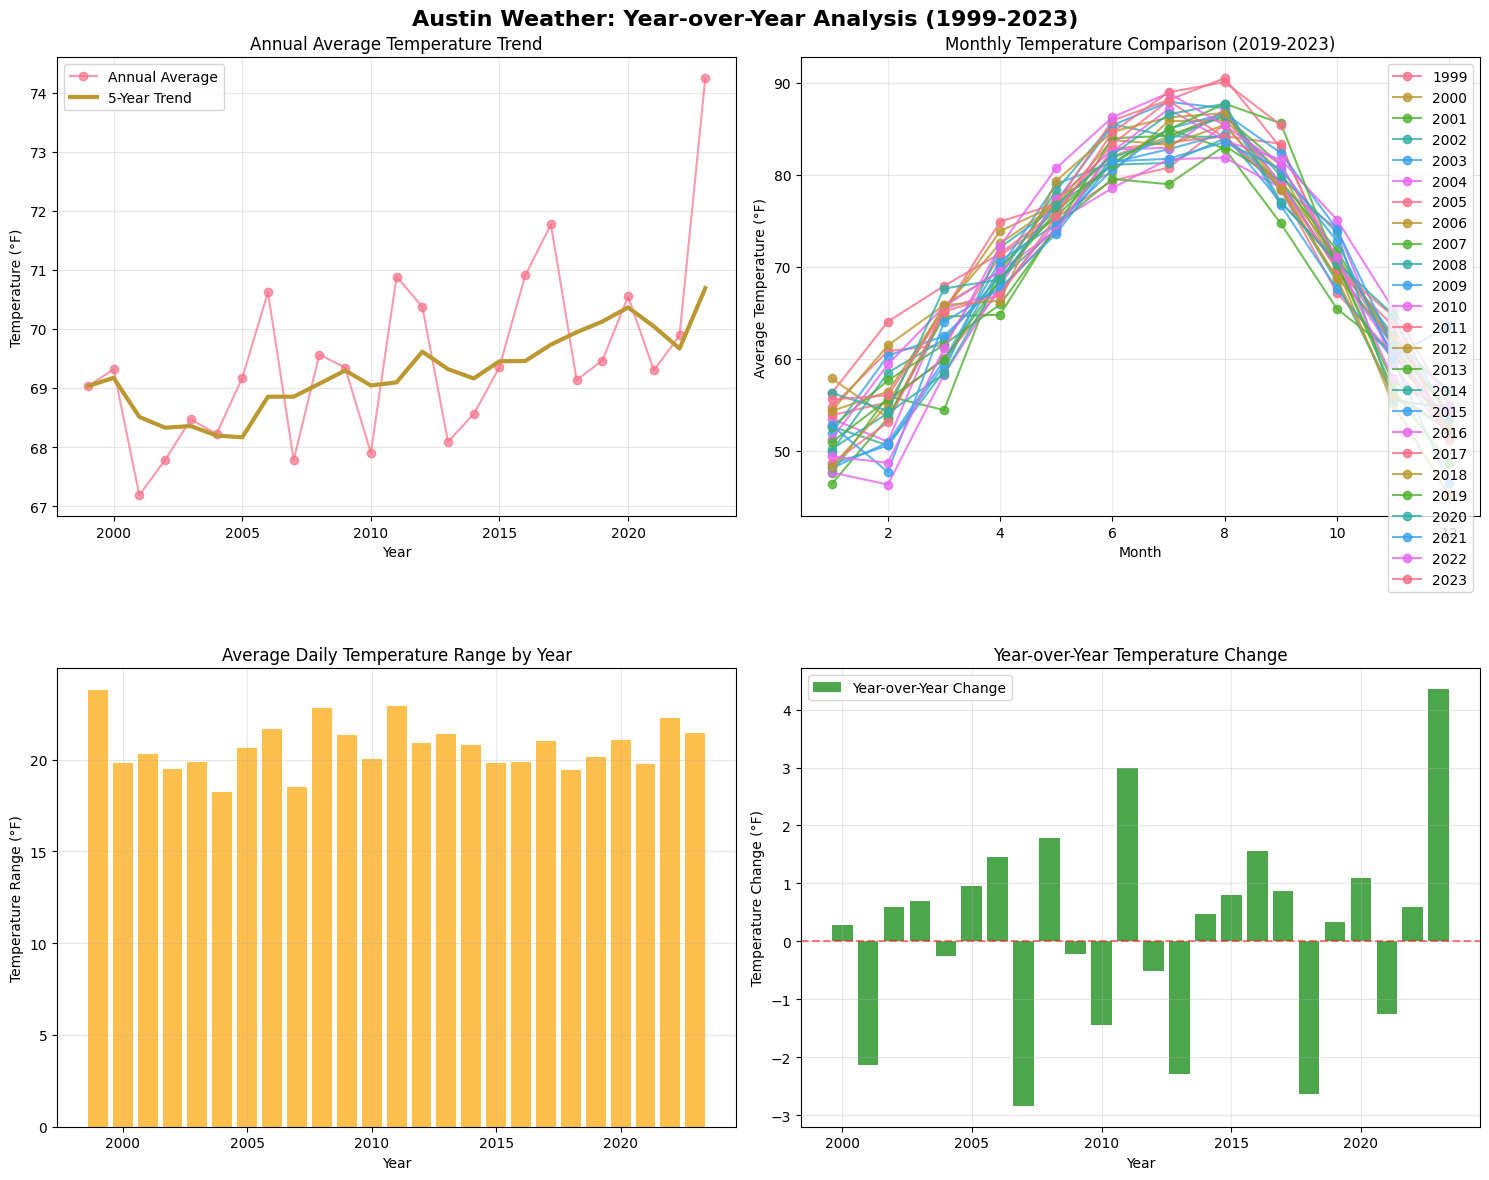

In [42]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Austin Weather: Year-over-Year Analysis (1999-2023)', fontsize=16, fontweight='bold')

# 1. Annual Average Temperature Trend
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempAvgF'], 'o-', alpha=0.7, label='Annual Average')
axes[0, 0].plot(annual_temps['Year'], annual_temps['TempTrend'], '-', linewidth=3, label='5-Year Trend')
axes[0, 0].set_title('Annual Average Temperature Trend')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Temperature (°F)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly Temperature Comparison (last 5 years)
# Not all years cause it looks messy
recent_years = monthly_comparison[monthly_comparison['Year'] >= 1999] 
for year in recent_years['Year'].unique():
    year_data = recent_years[recent_years['Year'] == year]
    axes[0, 1].plot(year_data['Month'], year_data['TempAvgF'], 'o-', label=f'{year}', alpha=0.8)
axes[0, 1].set_title('Monthly Temperature Comparison (2019-2023)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Temperature (°F)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Temperature Range Over Time
yearly_range = yoy_data.groupby('Year')['DailyTempRange'].mean().reset_index()
axes[1, 0].bar(yearly_range['Year'], yearly_range['DailyTempRange'], alpha=0.7, color='orange')
axes[1, 0].set_title('Average Daily Temperature Range by Year')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Temperature Range (°F)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Year-over-Year Temperature Change
axes[1, 1].bar(annual_temps['Year'][1:], annual_temps['YoY_Change'][1:], 
               alpha=0.7, color='green', label='Year-over-Year Change')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('Year-over-Year Temperature Change')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Temperature Change (°F)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


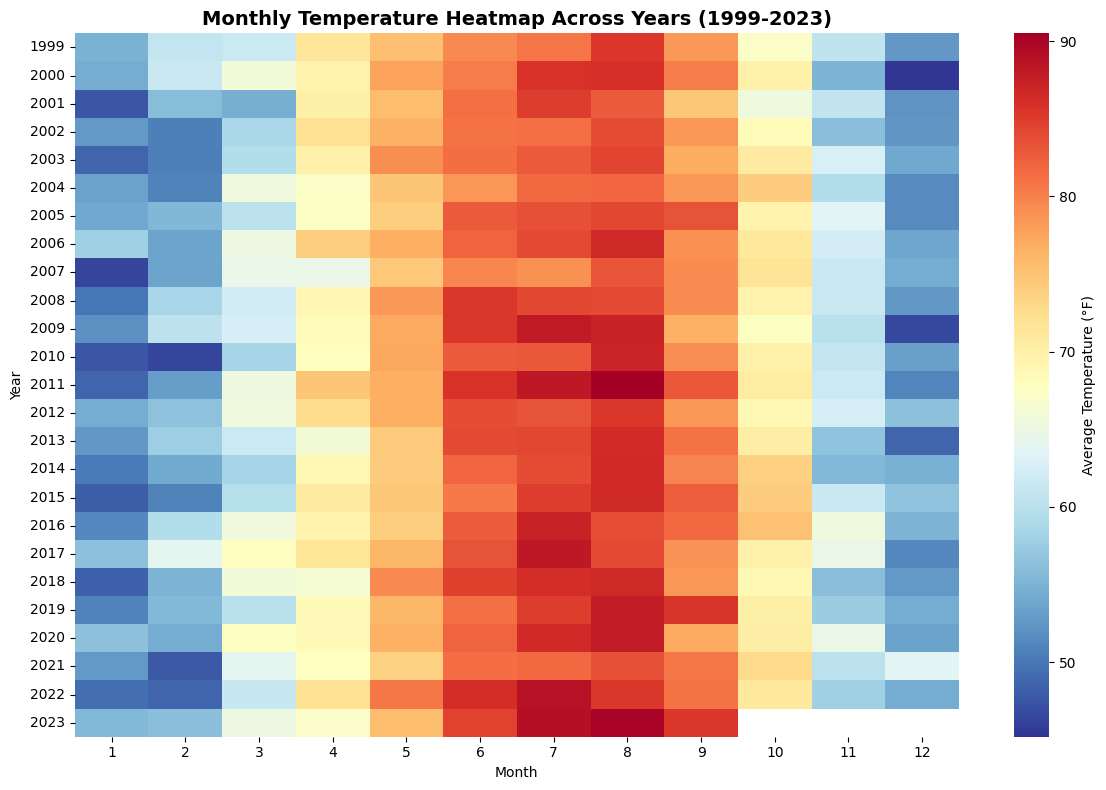

In [43]:
# Create a heatmap of monthly temperatures across years
plt.figure(figsize=(12, 8))

# Pivot data for heatmap
heatmap_data = monthly_comparison.pivot(index='Year', columns='Month', values='TempAvgF')

# Create heatmap
sns.heatmap(heatmap_data, annot=False, cmap='RdYlBu_r', cbar_kws={'label': 'Average Temperature (°F)'})
plt.title('Monthly Temperature Heatmap Across Years (1999-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


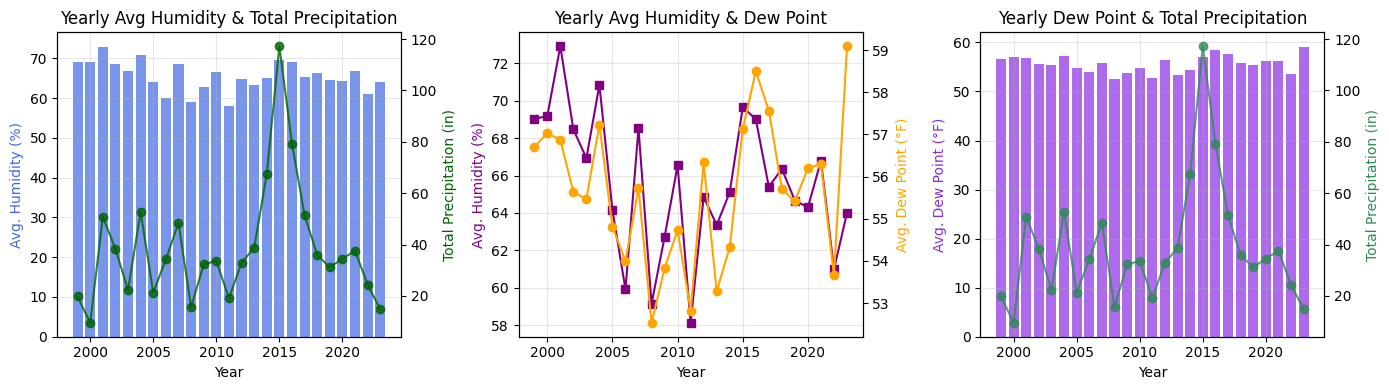

In [44]:
# Year-on-Year Analysis: Average Humidity, Dew Point, and Precipitation by Year

# Aggregate year-over-year data
yoy_year_summary = yoy_data.groupby('Year').agg({
    'HumidityAvgPercent': 'mean',
    'PrecipitationSumInches': 'sum',
    'DewPointAvgF': 'mean'
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Humidity vs. Precipitation (annual averages/sum by year)
axes[0].bar(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='royalblue', alpha=0.7, label='Avg. Humidity (%)')
ax2 = axes[0].twinx()
ax2.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='darkgreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg. Humidity (%)', color='royalblue')
ax2.set_ylabel('Total Precipitation (in)', color='darkgreen')
axes[0].set_title('Yearly Avg Humidity & Total Precipitation')
axes[0].grid(alpha=0.3)

# 2. Humidity vs. Dew Point (annual means)
axes[1].plot(yoy_year_summary['Year'], yoy_year_summary['HumidityAvgPercent'], color='purple', marker='s', label='Avg. Humidity (%)')
ax3 = axes[1].twinx()
ax3.plot(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='orange', marker='o', label='Avg. Dew Point (°F)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg. Humidity (%)', color='purple')
ax3.set_ylabel('Avg. Dew Point (°F)', color='orange')
axes[1].set_title('Yearly Avg Humidity & Dew Point')
axes[1].grid(alpha=0.3)

# 3. Dew Point vs. Precipitation (annual means/sum)
axes[2].bar(yoy_year_summary['Year'], yoy_year_summary['DewPointAvgF'], color='blueviolet', alpha=0.7, label='Avg. Dew Point (°F)')
ax4 = axes[2].twinx()
ax4.plot(yoy_year_summary['Year'], yoy_year_summary['PrecipitationSumInches'], color='seagreen', marker='o', alpha=0.8, label='Total Precipitation (in)')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Avg. Dew Point (°F)', color='blueviolet')
ax4.set_ylabel('Total Precipitation (in)', color='seagreen')
axes[2].set_title('Yearly Dew Point & Total Precipitation')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Step 9: Statistical Analysis of Temperature Changes


In [45]:
print("=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===")

# Calculate overall temperature trend
from scipy import stats

# Linear regression on annual temperatures
slope, intercept, r_value, p_value, std_err = stats.linregress(annual_temps['Year'], annual_temps['TempAvgF'])

print(f"Linear trend analysis:")
print(f"Slope (temperature change per year): {slope:.4f}°F/year")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Total change over 25 years: {slope * 25:.2f}°F")

# Calculate temperature statistics by decade
decade_stats = []
for decade in [1999, 2009, 2019]:
    decade_data = yoy_data[(yoy_data['Year'] >= decade) & (yoy_data['Year'] < decade + 10)]
    if len(decade_data) > 0:
        decade_stats.append({
            'Decade': f"{decade}s",
            'Avg_Temp': decade_data['TempAvgF'].mean(),
            'Max_Temp': decade_data['TempHighF'].max(),
            'Min_Temp': decade_data['TempLowF'].min(),
            'Temp_Range': decade_data['DailyTempRange'].mean()
        })

decade_df = pd.DataFrame(decade_stats)
print("\nTemperature statistics by decade:")
print(decade_df.round(2))

# Calculate hottest and coldest years
hottest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmax()]
coldest_year = annual_temps.loc[annual_temps['TempAvgF'].idxmin()]

print(f"\nHottest year: {hottest_year['Year']} ({hottest_year['TempAvgF']:.2f}°F)")
print(f"Coldest year: {coldest_year['Year']} ({coldest_year['TempAvgF']:.2f}°F)")


=== STATISTICAL ANALYSIS OF TEMPERATURE CHANGES ===
Linear trend analysis:
Slope (temperature change per year): 0.1151°F/year
R-squared: 0.3139
P-value: 0.0036
Total change over 25 years: 2.88°F

Temperature statistics by decade:
  Decade  Avg_Temp  Max_Temp  Min_Temp  Temp_Range
0  1999s     68.71     109.8      21.4       20.52
1  2009s     69.71     110.4      16.1       20.65
2  2019s     70.49     108.1       8.2       20.92

Hottest year: 2023.0 (74.25°F)
Coldest year: 2001.0 (67.18°F)


## Step 10: Final Data Summary and Export


In [72]:
print("=== FINAL DATA SUMMARY ===")

print(f"Original dataset: {data.shape}")
print(f"Cleaned dataset: {data_features.shape}")
print(f"Features added: {data_features.shape[1] - data.shape[1]}")

print("\nData quality summary:")
print(f"Missing values: {data_features.isnull().sum().sum()}")
print(f"Date range: {data_features['Date'].min().strftime('%Y-%m-%d')} to {data_features['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total days: {len(data_features)}")

print("\nTemperature statistics:")
print(f"Average temperature: {data_features['TempAvgF'].mean():.2f}°F")
print(f"Temperature range: {data_features['TempLowF'].min():.2f}°F to {data_features['TempHighF'].max():.2f}°F")
print(f"Average daily range: {data_features['DailyTempRange'].mean():.2f}°F")

print("\nData cleaning and feature engineering complete!")
print("Year-over-year analysis complete!")

# Export cleaned data
data_features.to_csv('Austin_Weather_Cleaned_99_23.csv', index=False)
print("\nCleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'")


=== FINAL DATA SUMMARY ===
Original dataset: (10354, 10)
Cleaned dataset: (10354, 27)
Features added: 17

Data quality summary:
Missing values: 2
Date range: 1999-01-01 to 2023-09-26
Total days: 10354

Temperature statistics:
Average temperature: 69.49°F
Temperature range: 8.20°F to 110.40°F
Average daily range: 20.65°F

Data cleaning and feature engineering complete!
Year-over-year analysis complete!

Cleaned data exported to 'Austin_Weather_Cleaned_99_23.csv'


**BELOW HERE**
what did i do?
- I copied the DataFrame and set `TempAvgF` as my target (assuming that's what we're mostly focused on?)
- Kept only numeric columns, dropped NAs, and removed a few unneeded fields.
- Ranked features by correlation with **TempAvgF** using **Pearson** and **Spearman**.
- Plotted heat maps for the avg temp f and other predictors (top pairs)
- Checked corr among predictors; listed pairs with |r| > 0.80.
- Wrote an IQR outlier function and counted outliers per numeric column:
  - overall
  - within each month (`Month` groupby).


Correlation analysis and outlier detection!

In [73]:
df_copy = data_features.copy()
#establish variables for what we're targetting
targetcol = "TempAvgF"
DOYcol = "DayOfYear"
monthcol = 'Month'
#pick number columns
print(df_copy.head())
num = df_copy.select_dtypes(include=[np.number]).copy()
num = num.dropna()

        Date  TempHighF  TempLowF  TempAvgF  DewPointAvgF  HumidityAvgPercent  \
0 1999-01-01       73.9      51.8      60.5          57.9                92.0   
1 1999-01-02       64.3      37.2      48.2          30.4                52.1   
2 1999-01-03       39.7      30.3      35.6          12.1                39.0   
3 1999-01-04       42.8      28.0      34.2          13.9                43.7   
4 1999-01-05       55.5      21.4      39.7          31.4                72.6   

   sealevelpressure  VisibilityAvgMiles  PrecipitationSumInches Events  Year  \
0            1008.7                 4.2                     0.0   None  1999   
1            1016.6                 9.7                     0.0   None  1999   
2            1029.8                 9.9                     0.0   None  1999   
3            1034.9                 9.9                     0.0   None  1999   
4            1026.7                 9.9                     0.0   None  1999   

   Month  Day  DayOfYear  Season

In [74]:
#drop unnecessary columns, then compute correlations for each column in association with avgtempf (in this)
dropcols = ['Year','Day',"TempAvgF_squared","HumidityAvgPercent_squared","Pressure_squared","HeatIndex"]
num = num.drop(columns=dropcols,errors="ignore")
corr = num.corr(method="pearson")
s = corr[targetcol].drop(labels=[targetcol]).dropna()
top_pearson = s.abs().sort_values(ascending=False)
print("correlations with average temperature with pearson method")
display(top_pearson)
print("correlations with avg temp with spearman")
corr = num.corr(method='spearman')
s = corr[targetcol].drop(labels=[targetcol]).dropna()
top_spearman = s.abs().sort_values(ascending=False)
display(top_spearman)

correlations with average temperature with pearson method


TempPressure              0.999795
TempHighF                 0.967104
TempLowF                  0.962247
PrevDayTemp               0.933342
TempAvg_7day              0.914485
DewPointAvgF              0.890428
sealevelpressure          0.636872
VisibilityAvgMiles        0.207234
Month                     0.184598
DayOfYear                 0.182471
HumidityAvg_7day          0.078546
DailyTempRange            0.042447
PrecipitationSumInches    0.038829
PrevDayHumidity           0.006330
HumidityAvgPercent        0.001927
Name: TempAvgF, dtype: float64

correlations with avg temp with spearman


TempPressure              0.999750
TempHighF                 0.971843
TempLowF                  0.963929
PrevDayTemp               0.946545
TempAvg_7day              0.935482
DewPointAvgF              0.871221
sealevelpressure          0.569677
DayOfYear                 0.195891
Month                     0.195750
VisibilityAvgMiles        0.124753
HumidityAvg_7day          0.104076
PrecipitationSumInches    0.102851
HumidityAvgPercent        0.055135
PrevDayHumidity           0.054166
DailyTempRange            0.040763
Name: TempAvgF, dtype: float64

gpt doing heatmap

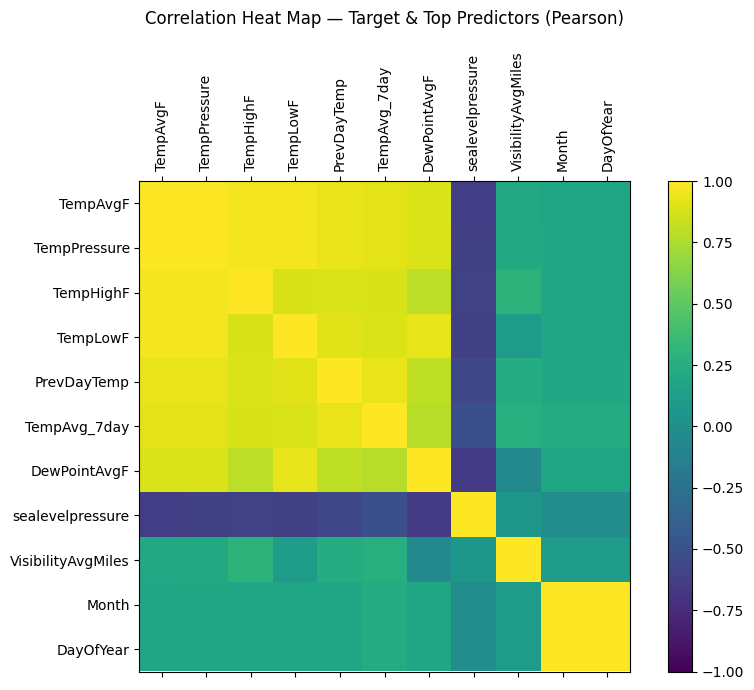

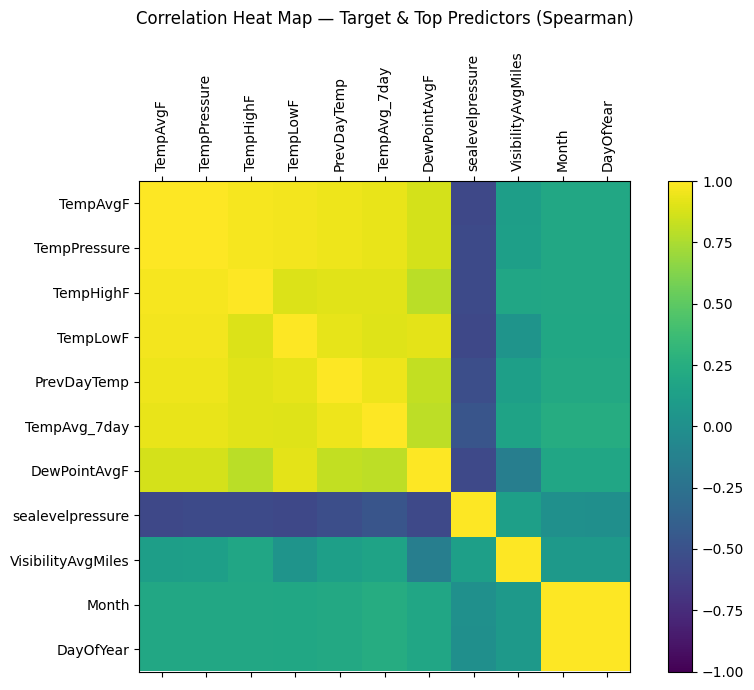

In [75]:
k_heat = min(10, len(top_pearson))
subset_cols = [targetcol] + top_pearson.index[:k_heat].tolist()

corr_sub = num[subset_cols].corr(method="pearson", numeric_only=True)

plt.figure(figsize=(9, 7))
ax = plt.gca()
cax = ax.matshow(corr_sub.values, vmin=-1, vmax=1)
plt.xticks(range(len(subset_cols)), subset_cols, rotation=90)
plt.yticks(range(len(subset_cols)), subset_cols)
plt.title("Correlation Heat Map — Target & Top Predictors (Pearson)", pad=20)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

# (Optional) Spearman heat map for stability check:
corr_sub_s = num[subset_cols].corr(method="spearman", numeric_only=True)
plt.figure(figsize=(9, 7))
ax = plt.gca()
cax = ax.matshow(corr_sub_s.values, vmin=-1, vmax=1)
plt.xticks(range(len(subset_cols)), subset_cols, rotation=90)
plt.yticks(range(len(subset_cols)), subset_cols)
plt.title("Correlation Heat Map — Target & Top Predictors (Spearman)", pad=20)
plt.colorbar(cax)
plt.tight_layout()
plt.show()


now do it for everything that is not temperature avg, above was just a more detailed analysis on specifically tempavgf (above 80 corr)

In [76]:
preds_only = [c for c in subset_cols if c != targetcol]
corr_pred = num[preds_only].corr(method="pearson", numeric_only=True).abs()

pairs = []
thr = 0.80
for i, a in enumerate(preds_only):
    for b in preds_only[i+1:]:
        val = corr_pred.loc[a, b]
        if pd.notna(val) and val > thr:
            pairs.append((a, b, float(val)))

collinearity_pairs = pd.DataFrame(pairs, columns=["feature_A","feature_B","abs_corr"]).sort_values("abs_corr", ascending=False)
print("|r| > 0 (negative or positive correlation, strong)")
display(collinearity_pairs if not collinearity_pairs.empty else pd.DataFrame(columns=["feature_A","feature_B","abs_corr"]))


|r| > 0 (negative or positive correlation, strong)


,feature_A,feature_B,abs_corr
14,Month,DayOfYear,0.996473
0,TempPressure,TempHighF,0.967157
1,TempPressure,TempLowF,0.961675
12,PrevDayTemp,TempAvg_7day,0.937131
2,TempPressure,PrevDayTemp,0.933604
11,TempLowF,DewPointAvgF,0.928795
3,TempPressure,TempAvg_7day,0.915714
9,TempLowF,PrevDayTemp,0.913915
6,TempHighF,PrevDayTemp,0.890557
10,TempLowF,TempAvg_7day,0.889151


find outliers with iqr of entire data

In [77]:
def iqrcheck(s,factor=1.5):
    s = s.astype(float) #just make sure it is a float lol
    q1,q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3-q1
    lowcheck,highcheck = q1-factor*iqr, q3+factor*iqr
    return (s<lowcheck) | (s>highcheck)

In [78]:
numcols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
summary = []
#loop through every column and find the outliers (only number columns!)
for col in  numcols:
    iqf = iqrcheck(df_copy[col])
    summary.append({"column":col,"# of iqr_outliers":int(iqf.sum())})
summary

[{'column': 'TempHighF', '# of iqr_outliers': 80},
 {'column': 'TempLowF', '# of iqr_outliers': 2},
 {'column': 'TempAvgF', '# of iqr_outliers': 6},
 {'column': 'DewPointAvgF', '# of iqr_outliers': 12},
 {'column': 'HumidityAvgPercent', '# of iqr_outliers': 49},
 {'column': 'sealevelpressure', '# of iqr_outliers': 296},
 {'column': 'VisibilityAvgMiles', '# of iqr_outliers': 995},
 {'column': 'PrecipitationSumInches', '# of iqr_outliers': 2309},
 {'column': 'Year', '# of iqr_outliers': 0},
 {'column': 'Month', '# of iqr_outliers': 0},
 {'column': 'Day', '# of iqr_outliers': 0},
 {'column': 'DayOfYear', '# of iqr_outliers': 0},
 {'column': 'DailyTempRange', '# of iqr_outliers': 86},
 {'column': 'TempAvgF_squared', '# of iqr_outliers': 0},
 {'column': 'HumidityAvgPercent_squared', '# of iqr_outliers': 43},
 {'column': 'Pressure_squared', '# of iqr_outliers': 309},
 {'column': 'HeatIndex', '# of iqr_outliers': 0},
 {'column': 'TempPressure', '# of iqr_outliers': 6},
 {'column': 'PrevDayTem

since this is based on just everything, we should probably let it compute the iqr flags within each month/ also within each season

In [79]:
summary_months = []

for col in numcols:
    iqf = df_copy.groupby(monthcol, group_keys=False)[col].apply(lambda s: iqrcheck(s))
    summary_months.append({"column":col,"# of iqr outliers":int(iqf.sum())})
summary_months



[{'column': 'TempHighF', '# of iqr outliers': 190},
 {'column': 'TempLowF', '# of iqr outliers': 90},
 {'column': 'TempAvgF', '# of iqr outliers': 105},
 {'column': 'DewPointAvgF', '# of iqr outliers': 212},
 {'column': 'HumidityAvgPercent', '# of iqr outliers': 102},
 {'column': 'sealevelpressure', '# of iqr outliers': 73},
 {'column': 'VisibilityAvgMiles', '# of iqr outliers': 844},
 {'column': 'PrecipitationSumInches', '# of iqr outliers': 2281},
 {'column': 'Year', '# of iqr outliers': 0},
 {'column': 'Month', '# of iqr outliers': 0},
 {'column': 'Day', '# of iqr outliers': 0},
 {'column': 'DayOfYear', '# of iqr outliers': 0},
 {'column': 'DailyTempRange', '# of iqr outliers': 117},
 {'column': 'TempAvgF_squared', '# of iqr outliers': 59},
 {'column': 'HumidityAvgPercent_squared', '# of iqr outliers': 100},
 {'column': 'Pressure_squared', '# of iqr outliers': 72},
 {'column': 'HeatIndex', '# of iqr outliers': 115},
 {'column': 'TempPressure', '# of iqr outliers': 105},
 {'column': 

In [ ]:
summary_seasons = []



for col in numcols:
    iqf = df_copy.groupby("Season",group_keys=False)[col].apply(lambda s: iqrcheck(s))
    summary_seasons.append({"column":col,"# of iqr outliers":int(iqf.sum())})


summary_seasons
num.head()

,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Month,DayOfYear,DailyTempRange,TempPressure,PrevDayTemp,PrevDayHumidity,TempAvg_7day,HumidityAvg_7day
1,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,1,2,27.1,49000.12,60.5,92.0,54.350,72.050000
2,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,1,3,9.4,36660.88,48.2,52.1,48.100,61.033333
3,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,1,4,14.8,35393.58,35.6,39.0,44.625,56.700000
4,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,1,5,34.1,40759.99,34.2,43.7,43.640,59.880000
5,62.3,44.7,54.2,52.1,93.0,1019.9,7.6,0.0,1,6,17.6,55278.58,39.7,72.6,45.400,65.400000
